# 1. Installation des bibliothèques nécessaires

In [4]:
# Installer les dépendances
!pip install -q kaggle
!pip install -q tensorflow tensorflowjs


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.32.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [5]:
!pip install -q kaggle
!pip install -q tensorflow tensorflowjs
!pip install -q packaging==23.2


In [6]:
# 2. Charger kaggle.json depuis ton environnement (upload requis si pas déjà fait)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"inesdahmani11","key":"8fc31b8cfcc0ca17b15ed70da44bcf53"}'}

# 2. Accès à Google Drive & configuration Kaggle

In [8]:

#  Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

#  Configuration de l'API Kaggle
!mkdir -p ~/.kaggle
!cp '/content/drive/MyDrive/kaggle.json' ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [9]:
# Télécharge le dataset
!kaggle datasets download -d emmarex/plantdisease

# Dézippe le fichier téléchargé
!unzip plantdisease.zip -d /content/plant_disease_dataset


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: /content/plant_disease_dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: /content/plant_disease_dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: /content/plant_disease_dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: /content/plant_disease_dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: /content/plant_disease_dataset/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: /content/plant_disease_dataset/plantvillage/PlantVil

In [10]:
# . Vérifier les fichiers extraits
import os
print("Contenu du dossier :")
print(os.listdir('/content/plant_disease_dataset'))

Contenu du dossier :
['PlantVillage', 'plantvillage']


# 4. Préparation des données

In [11]:
# 🧠 Préparation des données avec ImageDataGenerator
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = '/content/plant_disease_dataset'
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 33022 images belonging to 2 classes.
Found 8254 images belonging to 2 classes.


# 5. Création du modèle CNN

In [12]:
from tensorflow.keras import layers, models

num_classes = train_generator.num_classes

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Entraînement

In [13]:
EPOCHS = 10
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 500s 477ms/step - accuracy: 0.4993 - loss: 0.7172 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 485s 470ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 482s 467ms/step - accuracy: 0.4954 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 491s 476ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 487s 472ms/step - accuracy: 0.4984 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 483s 468ms/step - accuracy: 0.5024 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 482s 467ms/step - accuracy: 0.4973 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 482s 467ms/step - ac

# 7. Visualisation

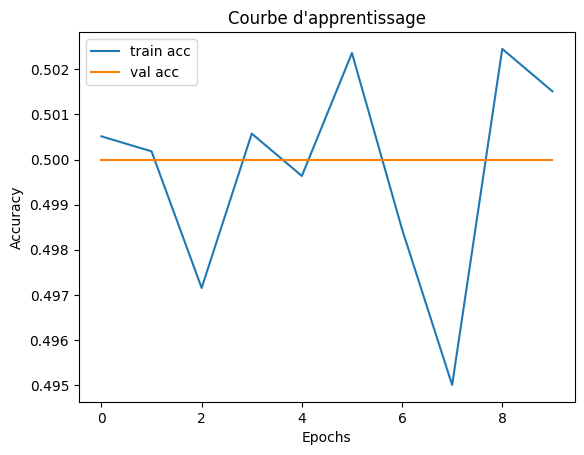

In [14]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Courbe d'apprentissage")
plt.show()


# 8. Matrice de confusion

258/258 ━━━━━━━━━━━━━━━━━━━━ 97s 373ms/step


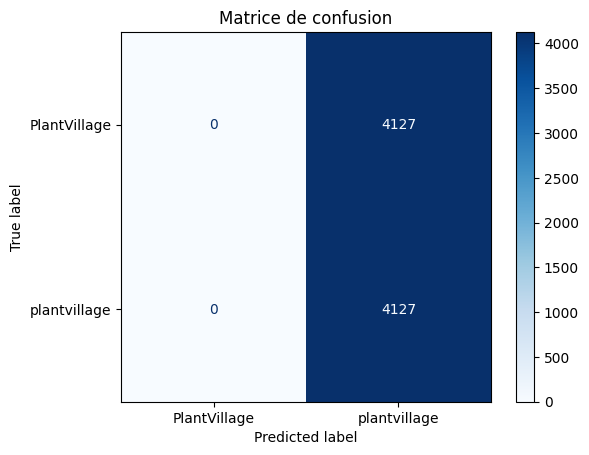

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()




# 9. Fonction de prédiction sur image

In [16]:
from tensorflow.keras.preprocessing import image

def charger_et_predire(image_path, model_path, img_size=224, class_names=None):
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(image_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    confidence = np.max(prediction)
    predicted_class = class_names[np.argmax(prediction)] if class_names else np.argmax(prediction)
    return predicted_class, confidence


# 10. Sauvegarde et téléchargement du modèle

In [17]:

model.save("model_maladie_plante.keras")
from google.colab import files
files.download("model_maladie_plante.keras")  # Téléchargement



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 11. Test avec image de l’utilisateur

In [18]:

# 10. Prédire une image chargée par l’utilisateur
from tensorflow.keras.preprocessing import image
import numpy as np

# Lister les classes
class_names = list(train_generator.class_indices.keys())
print("Classes :", class_names)

# Charger une image pour test
from google.colab import files
uploaded = files.upload()  # <- Uploade ici une image de feuille malade ou saine

img_path = list(uploaded.keys())[0]


Classes : ['PlantVillage', 'plantvillage']


Saving plante malade.JPG to plante malade.JPG


In [19]:
# Fonction de prédiction
def charger_et_predire_affichage(image_path, model_path, img_size=224, class_names=None):
    model = tf.keras.models.load_model(model_path)

    img = image.load_img(image_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    confidence = np.max(prediction)
    predicted_class = class_names[np.argmax(prediction)] if class_names else np.argmax(prediction)

    # Affichage avec matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    img = mpimg.imread(image_path)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"🌿 Résultat : {predicted_class} ({confidence*100:.2f}%)", fontsize=14, color='green')
    plt.show()

    return predicted_class, confidence


Saving plante malade.JPG to plante malade (2).JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Score de prédiction : [0.498488 0.501512]


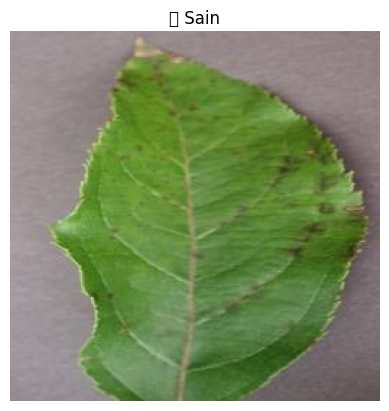

In [24]:
model = tf.keras.models.load_model("model_maladie_plante.keras")

from google.colab import files
uploaded = files.upload()

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path):
    image = Image.open(img_path).convert("RGB")
    image = image.resize((224, 224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    return image

img_path = list(uploaded.keys())[0]
img = preprocess_image(img_path)
pred = model.predict(img)[0]

print("Score de prédiction :", pred)


plt.imshow(Image.open(img_path))
plt.axis('off')
plt.title(label)
plt.show()


In [33]:
import requests

# Remplace par l'URL publique de ton API (ngrok ou hébergement)
url = "https://xxxxxx.ngrok.io/api/predictions"

file_path = '/content/plante malade.JPG'  # Image uploadée dans Colab

files = {'image': open(file_path, 'rb')}

response = requests.post(url, files=files)

print("Status Code:", response.status_code)



Status Code: 404


In [22]:
# 📦 1. Installer les dépendances
!pip install flask-ngrok tensorflow pillow

# 📚 2. Importations
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
import tensorflow as tf
import numpy as np
from PIL import Image
import io

# 📁 3. Charger le modèle entraîné
model_path = "/content/model_maladie_plante.keras"  # ← change ce chemin si nécessaire
model = tf.keras.models.load_model(model_path)
print("✅ Modèle chargé :", model_path)

# 🧼 4. Prétraitement d'image
def preprocess_image(img_bytes):
    image = Image.open(io.BytesIO(img_bytes)).resize((224, 224)).convert("RGB")
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    return image

# 🧠 5. Classes du modèle (change selon ton entraînement)
class_names = ["Saine", "Tache noire", "Rouille"]  # ← adapte à ton dataset

# 🌐 6. Créer l’API Flask
app = Flask(__name__)
run_with_ngrok(app)

@app.route('/predict', methods=['POST'])
def predict():
    if 'image' not in request.files:
        return jsonify({'error': 'Aucune image reçue'}), 400

    image = request.files['image'].read()
    processed = preprocess_image(image)
    prediction = model.predict(processed)[0]

    predicted_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction))

    return jsonify({
        "label": predicted_class,
        "confidence": round(confidence * 100, 2)
    })

# 🚀 7. Démarrer le serveur
print("🚀 Serveur lancé sur ngrok...")
app.run()



✅ Modèle chargé : /content/model_maladie_plante.keras
🚀 Serveur lancé sur ngrok...
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-22:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.11/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
           